# Memory Agent 
- An agent which replies and stores the converstation

### Main Goal: Create a form of memory for our Agent

## Objectives:
1. Use different message types - HumanMessage and AIMessage
2. Maintain a full conversation history using both message types
3. Use llm model (Groq) using LangChain's ChatGroq
4. Create a sophisticated conversation loop

In [1]:
from typing import TypedDict, List, Union
from langchain_core.messages import HumanMessage, AIMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
class AgentState(TypedDict):
    messages: List[Union[HumanMessage, AIMessage]]

In [3]:
import os
Groq_API_Key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(api_key=Groq_API_Key, model="llama-3.1-8b-instant", temperature=0)

In [4]:
def pretty_print(state: AgentState) -> AgentState:
    for message in state["messages"]:
        if isinstance(message, HumanMessage):
            print(f"\nHuman: {message.content}")
        elif isinstance(message, AIMessage):
            print(f"\nAI: {message.content}")
    print("=-=-" * 20)
    return state

In [5]:
def process(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    state["messages"].append(AIMessage(content=response.content))
    pretty_print(state)
    return state

In [6]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)

chatbot = graph.compile()

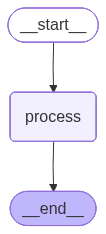

In [7]:
from IPython.display import Image, display
display(Image(chatbot.get_graph().draw_mermaid_png()))

In [9]:
conversation_history = []

user_input = input("Enter: ")
while user_input != "exit":
    conversation_history.append(HumanMessage(content=user_input))
    result = chatbot.invoke({"messages": conversation_history})
    conversation_history = result["messages"]
    user_input = input("Enter: ")


Human: tell me game of thrones joke 

AI: Why did Jon Snow bring a ladder to the Night's Watch?

Because he wanted to take his vows to the next level.
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-

Human: tell me game of thrones joke 

AI: Why did Jon Snow bring a ladder to the Night's Watch?

Because he wanted to take his vows to the next level.

Human: who is the lead character in games of throne

AI: The show "Game of Thrones" has multiple lead characters, but some of the main ones include:

1. Daenerys Targaryen (played by Emilia Clarke) - The Mother of Dragons and a key player in the battle for the Iron Throne.
2. Jon Snow (played by Kit Harington) - The bastard son of Ned Stark and a key player in the battle for the North and the Iron Throne.
3. Tyrion Lannister (played by Peter Dinklage) - A dwarf and a member of House Lannister, known for his wit and cunning.
4. Cersei Lannister (played by Lena Headey) - The Queen Regent of the Seven Kingdoms

In [10]:
print(conversation_history)

[HumanMessage(content='tell me game of thrones joke ', additional_kwargs={}, response_metadata={}), AIMessage(content="Why did Jon Snow bring a ladder to the Night's Watch?\n\nBecause he wanted to take his vows to the next level.", additional_kwargs={}, response_metadata={}), HumanMessage(content='who is the lead character in games of throne', additional_kwargs={}, response_metadata={}), AIMessage(content='The show "Game of Thrones" has multiple lead characters, but some of the main ones include:\n\n1. Daenerys Targaryen (played by Emilia Clarke) - The Mother of Dragons and a key player in the battle for the Iron Throne.\n2. Jon Snow (played by Kit Harington) - The bastard son of Ned Stark and a key player in the battle for the North and the Iron Throne.\n3. Tyrion Lannister (played by Peter Dinklage) - A dwarf and a member of House Lannister, known for his wit and cunning.\n4. Cersei Lannister (played by Lena Headey) - The Queen Regent of the Seven Kingdoms and a key player in the bat

In [12]:
with open("Conversation_Log.txt", "w") as file:
    file.write("Your Conversation Log:\n")
    
    for message in conversation_history:
        if isinstance(message, HumanMessage):
            file.write(f">>You: {message.content}\n")
        elif isinstance(message, AIMessage):
            file.write(f">>AI: {message.content}\n\n")
    file.write("End of Conversation")

print("Conversation saved to Conversation_Log.txt")

Conversation saved to Conversation_Log.txt
